# Inventory Policy Classes — End-to-End Planning

OptiStock provides four concrete planning classes. Each class *is* a replenishment policy:
instantiate the one that matches your operating model and call `run_holdout()` or `run()`.

| Class | Policy | Description |
|---|---|---|
| `PeriodicOrderUpTo` | (R, S) | Profit-maximising periodic review |
| `PeriodicBaseStock` | (R, S) + CSL | Periodic review with mandatory service-level floor |
| `ContinuousFixedQuantity` | (s, Q) | Continuous review — fixed order quantity |
| `ContinuousOrderUpTo` | (s, S) | Continuous review — order up to a target level |

**Periodic policies** review inventory every `review_period` days and solve the newsvendor
problem over the protection interval (`lead_time + review_period`). They return an
`allocation` (gross order) and `net_allocation` (gross − on_hand − on_order).

**Continuous policies** monitor inventory daily and trigger an order whenever the
inventory position falls to or below reorder point `s`. They return a
`reorder_distribution` — the distribution of *days-to-first-reorder* across all
Bayesian posterior demand scenarios — rather than a fixed order quantity.

History: 1,460 rows  |  730 days  |  2022-01-01 → 2023-12-31

Item configurations:
      name  cost_price  selling_price  salvage_value  lead_time  storage_m3
Tablet Air         120            250             40          5         1.2
Laptop Pro         400            750            100          5         2.0


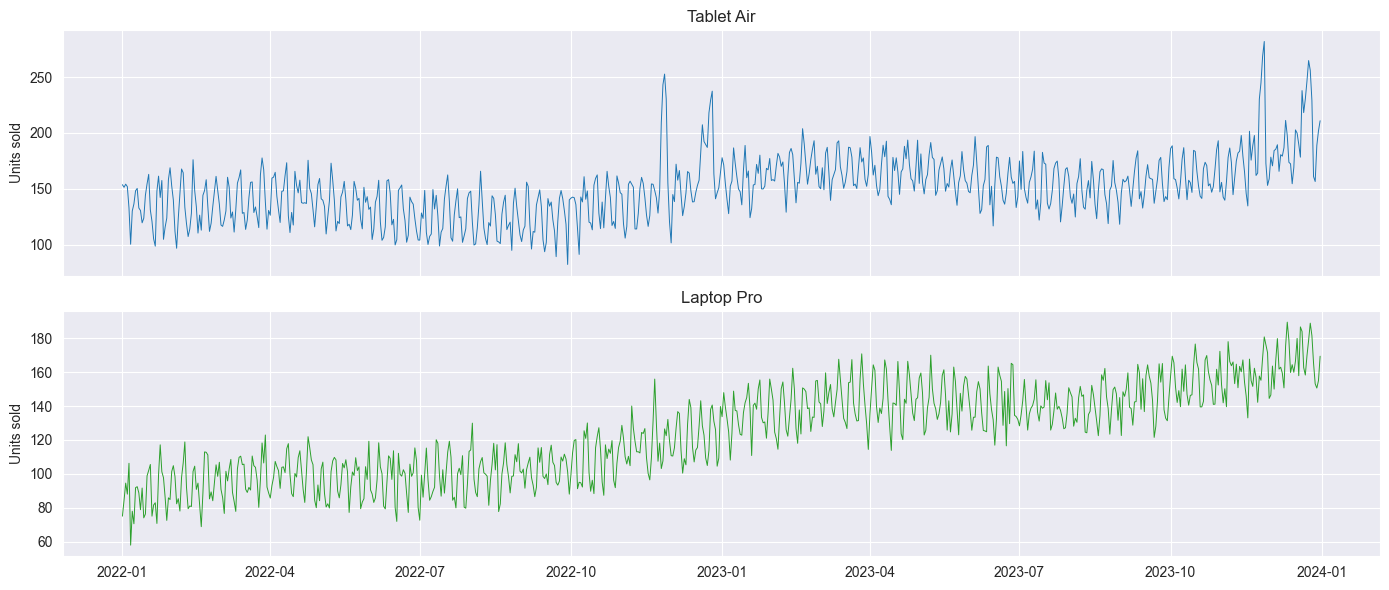

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)

# ── Synthetic histories ────────────────────────────────────────────────────
N = 730
dates = pd.date_range("2022-01-01", periods=N, freq="D")
t = np.arange(N)

# Tablet Air — consumer electronics with promotions and imperfect yield
trend_ta  = 120 + 0.08 * t
weekly_ta = 18 * np.sin(2 * np.pi * t / 7) + 8 * np.cos(2 * np.pi * t / 7)
yearly_ta = 12 * np.sin(2 * np.pi * t / 365.25) + 8 * np.cos(2 * np.pi * t / 365.25)
event_ta  = np.zeros(N)
for i, d in enumerate(dates):
    if d.month == 11 and d.weekday() == 4 and 22 <= d.day <= 28:   # Black Friday
        event_ta[i : min(i + 4, N)] += 80
    if d.month == 12 and 20 <= d.day <= 26:                         # Christmas week
        event_ta[i] += 60
sales_ta = trend_ta + weekly_ta + yearly_ta + event_ta + np.random.normal(0, 10, N)

# Laptop Pro — enterprise, smoother demand
trend_lp  = 80 + 0.12 * t
weekly_lp = 12 * np.sin(2 * np.pi * t / 7) - 6 * np.cos(2 * np.pi * t / 7)
yearly_lp = 8 * np.sin(2 * np.pi * t / 365.25) + 5 * np.cos(2 * np.pi * t / 365.25)
sales_lp  = trend_lp + weekly_lp + yearly_lp + np.random.normal(0, 8, N)

df_history = pd.concat([
    pd.DataFrame({"item": "Tablet Air", "date": dates.astype(str),
                  "sales": np.maximum(sales_ta, 5).round(1)}),
    pd.DataFrame({"item": "Laptop Pro",  "date": dates.astype(str),
                  "sales": np.maximum(sales_lp, 5).round(1)}),
], ignore_index=True)

# ── Item configuration ─────────────────────────────────────────────────────
# lead_time: calendar days from order placement to arrival.
# Used by all policy classes to compute the planning horizon.
item_configs = pd.DataFrame([
    {"name": "Tablet Air", "cost_price": 120, "selling_price": 250,
     "salvage_value":  40, "lead_time": 5, "storage_m3": 1.2},
    {"name": "Laptop Pro",  "cost_price": 400, "selling_price": 750,
     "salvage_value": 100, "lead_time": 5, "storage_m3": 2.0},
])

# ── Shared forecaster + yield config ──────────────────────────────────────
from optistock.forecasting.linear_regressors import BayesTimeSeries
from optistock.distributions.yield_distributions import BetaYield

seasonal_config = {"weekly": (7, 3), "yearly": (365.25, 4)}

# Tablet Air has uncertain yield: ~80 % of ordered units pass QC
yield_profiles = {"Tablet Air": BetaYield(8, 2)}

# ── Promotional events for Tablet Air ─────────────────────────────────────
all_dates  = pd.to_datetime(df_history["date"].unique())
bf_dates   = [d for d in all_dates if d.month == 11 and d.weekday() == 4 and 22 <= d.day <= 28]
xmas_dates = [d for d in all_dates if d.month == 12 and 20 <= d.day <= 26]
events = {
    "Tablet Air": {
        "black_friday": [str(d.date()) for d in bf_dates],
        "christmas":    [str(d.date()) for d in xmas_dates],
    }
}

# ── Single-item subset for continuous-review sections (Parts 3 & 4) ───────
df_tablet          = df_history[df_history["item"] == "Tablet Air"].copy()
item_configs_tablet = item_configs[item_configs["name"] == "Tablet Air"].reset_index(drop=True)

print(f"History: {df_history.shape[0]:,} rows  |  {N} days  |  "
      f"{df_history['date'].min()} → {df_history['date'].max()}")
print(f"\nItem configurations:")
print(item_configs.to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax, item, c in zip(axes, ["Tablet Air", "Laptop Pro"], ["tab:blue", "tab:green"]):
    sub = df_history[df_history["item"] == item]
    ax.plot(pd.to_datetime(sub["date"]), sub["sales"], lw=0.7, color=c)
    ax.set_title(item); ax.set_ylabel("Units sold")
plt.tight_layout()

---
## Part 1 — `PeriodicOrderUpTo` (R, S)

Review inventory every `review_period` days and order to cover the **protection interval**:

> **planning horizon = lead_time + review_period**

The solver maximises expected profit (SAA), CVaR, or exponential utility over the full
posterior demand distribution for that window.

| Parameter | Where | Description |
|---|---|---|
| `review_period` | constructor | Days between replenishment reviews (≥ 1) |
| `inventory_state` | `run()` / `run_holdout()` | `{item: {"on_hand": int, "on_order": int}}` — deducted from gross order |

**Returns:** `allocation` (gross order), `net_allocation` (gross − on_hand − on_order),
`solver_summary`, and in holdout mode, `metrics` (profit, service level, SMAPE, …).

In [2]:
from optistock.stockkeep import PeriodicOrderUpTo

# Horizon per item = lead_time + review_period = 5 + 7 = 12 days
sk = PeriodicOrderUpTo(
    histories=df_history,
    item_configs=item_configs,
    review_period=7,
    forecaster_class=BayesTimeSeries,
    forecaster_kwargs={"seasonal_config": seasonal_config},
    yield_profiles=yield_profiles,
)

# Holdout: withhold the last 12 days (= lead_time + review_period for both items)
results = sk.run_holdout(
    holdout_days=12,
    events=events,
    objective="CVaR",
    limits={"storage_m3": 7_000},
    cvar_alpha=0.10,
    cvar_lambda=0.4,
    fit_kwargs={"chain": 2, "samples": 500},
)

print(f"Planning period : {results['period'][0]}  →  {results['period'][1]}")
print(f"Mode            : {results['mode']}")
print()
print(f"{'Item':<14} {'Gross Q*':>9} {'Profit':>12} {'Service':>9} {'Stockout':>9} {'SMAPE':>7}")
print("─" * 60)
for item in sk.items:
    m    = results["metrics"][item.name]
    qty  = results["allocation"][item.name]
    smape = f"{m['smape_pct']:.1f}%" if "smape_pct" in m else "—"
    flag  = "Yes ⚠" if m["stockout"] else "No ✓"
    print(f"  {item.name:<12} {qty:>9,} {m['profit']:>12,.0f} "
          f"{m['service_level']:>8.1%} {flag:>9}  {smape:>6}")
print()
print(f"  Portfolio profit : R {results['metrics']['portfolio_total_profit']:>12,.0f}")
shadow = results["solver_summary"].get("shadow_prices", {}).get("storage_m3", 0)
print(f"  Shadow price (storage_m3) : R {shadow:.2f} / m³")

Initializing NUTS using jitter+adapt_diag...
c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, growth, beta_event, beta_fourier, sigma]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 21 seconds.
Sampling: [y]


Output()

Sampling: [y]


...

Output()

Sampling: [y]


Output()

Planning period : 2023-12-20  →  2023-12-31
Mode            : holdout

Item            Gross Q*       Profit   Service  Stockout   SMAPE
────────────────────────────────────────────────────────────
  Tablet Air       2,488      323,440    95.6%     Yes ⚠    3.5%
  Laptop Pro       2,006      702,100    99.4%     Yes ⚠    3.9%

  Portfolio profit : R    1,025,540
  Shadow price (storage_m3) : R 45.48 / m³


C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\solvers.py:285: RuntimeWarning: divide by zero encountered in divide
  eu = float(np.mean(np.exp(-profits / self.risk_aversion)))


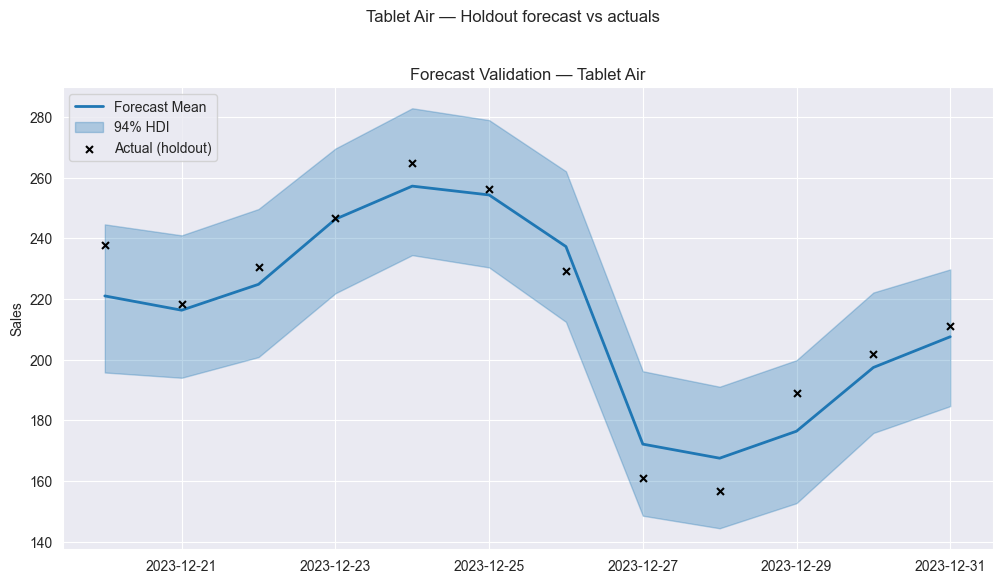

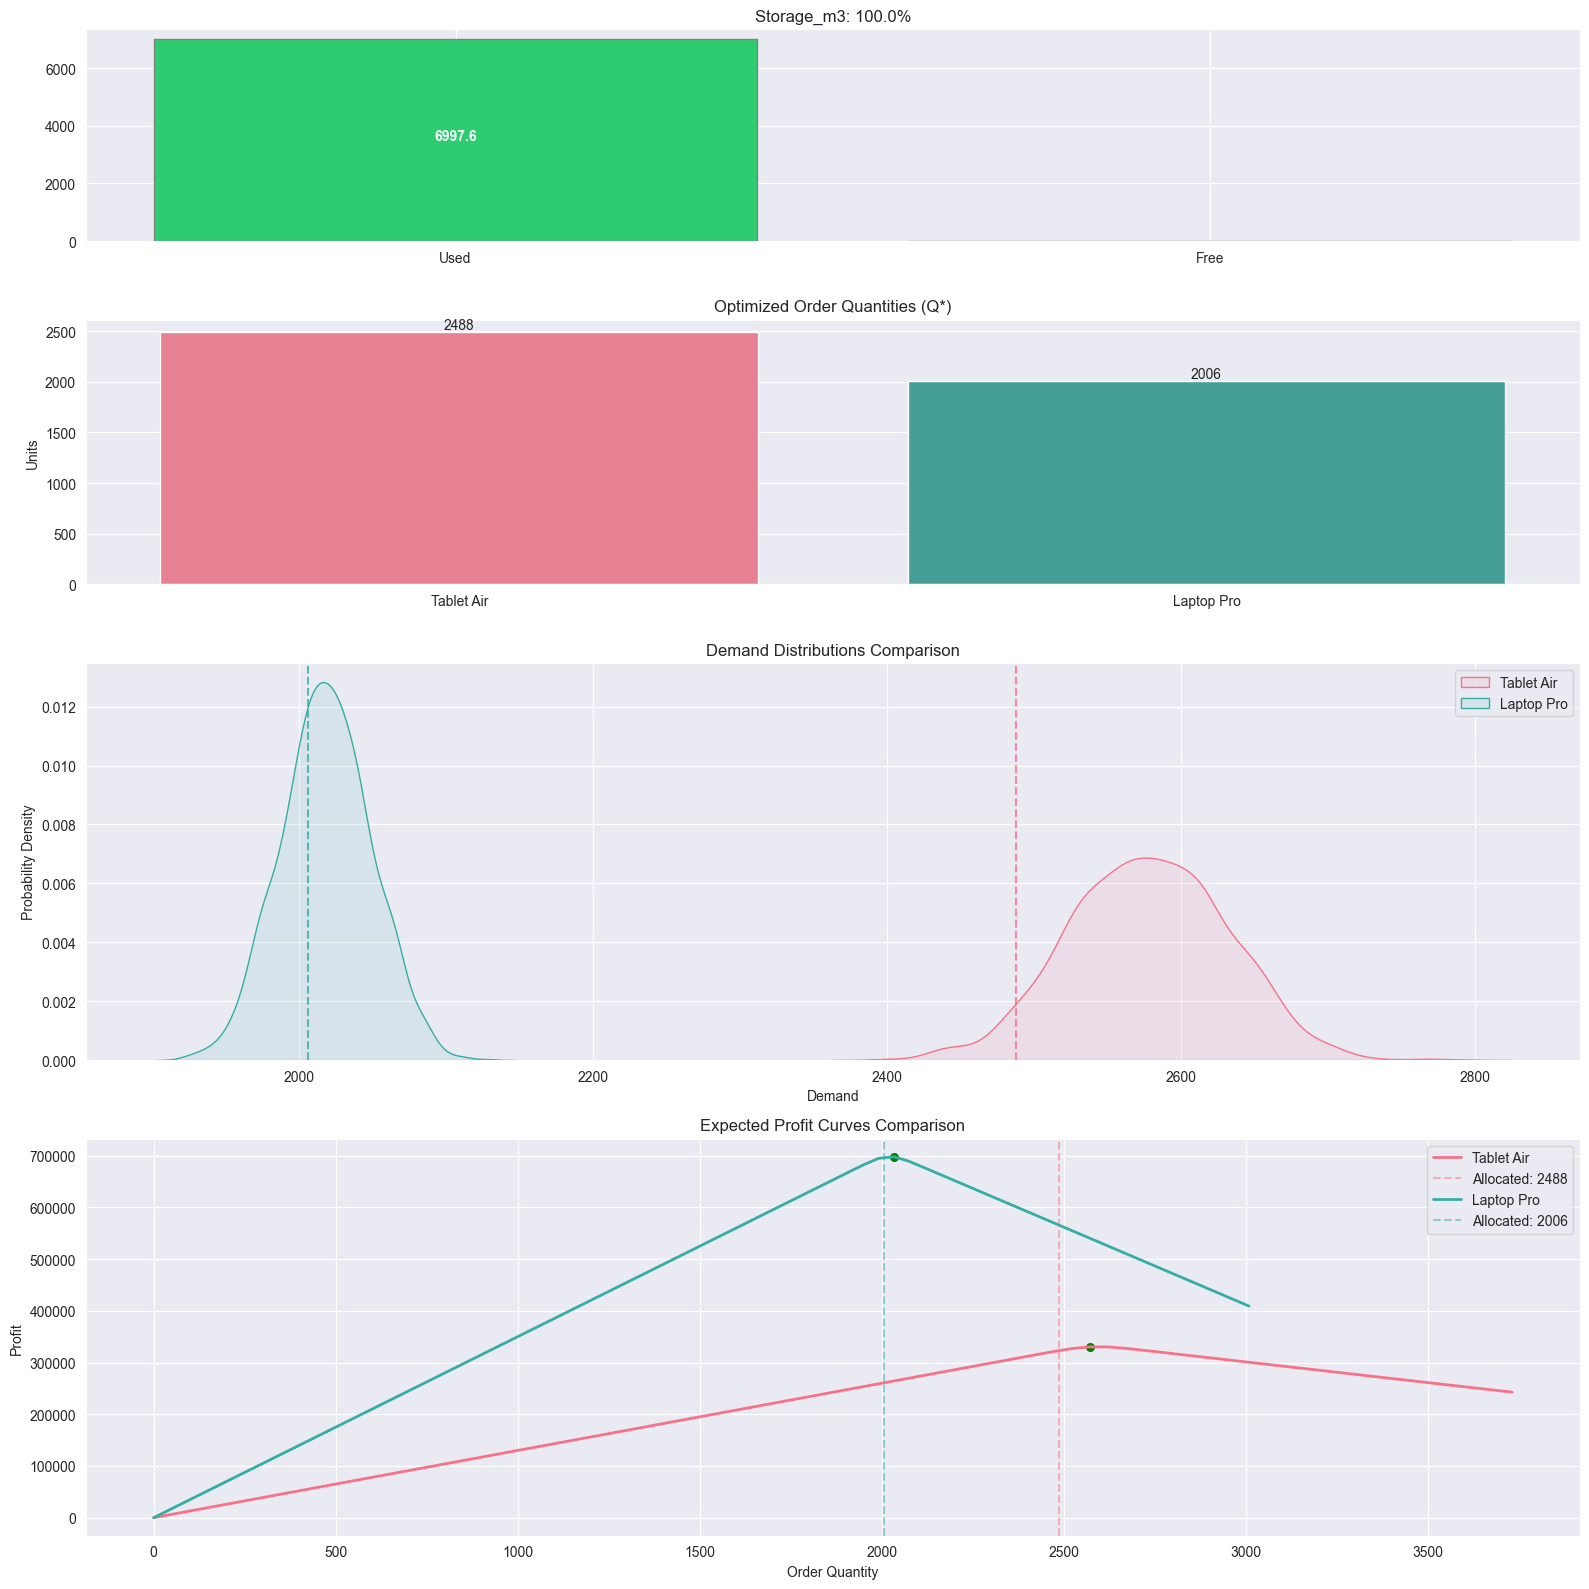

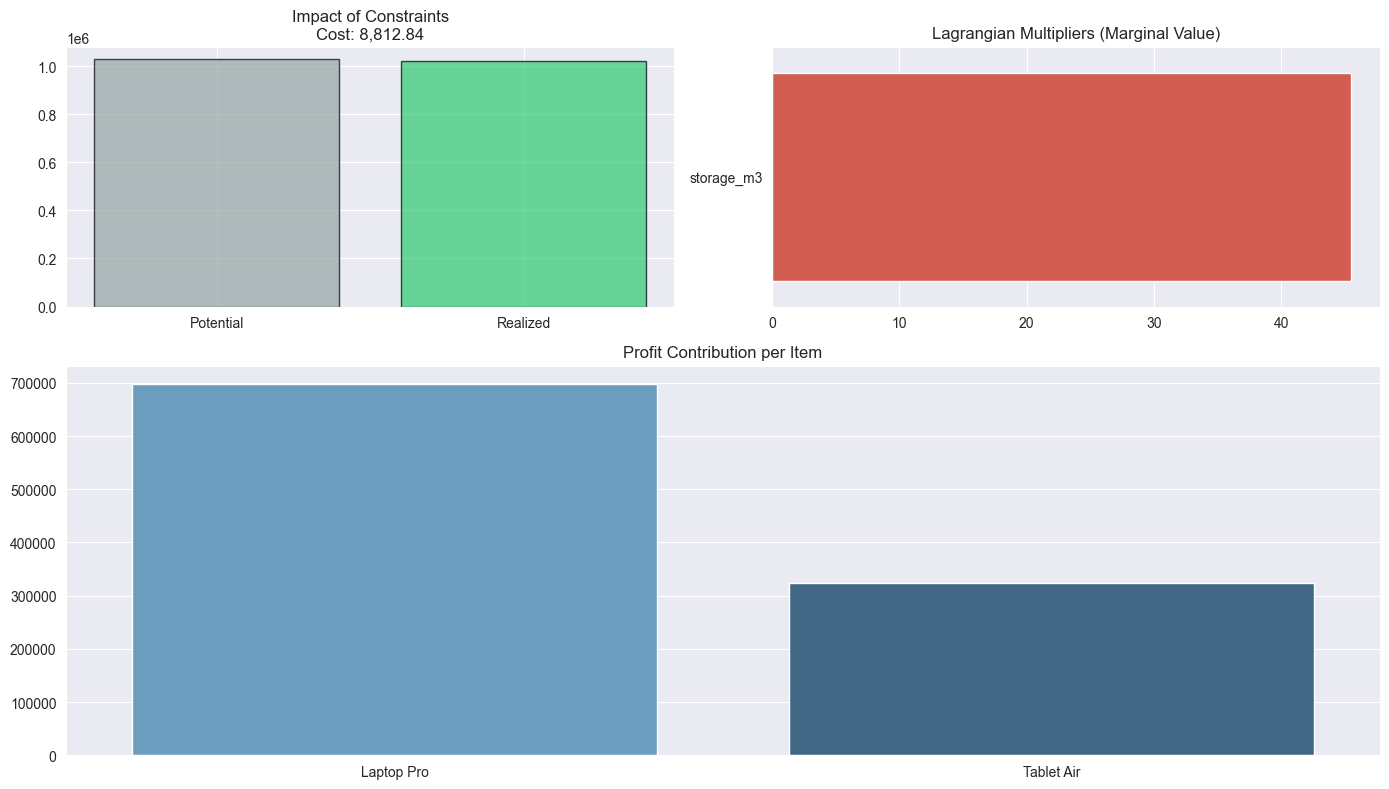

In [3]:
# Forecast vs actuals — well-calibrated model has actuals inside the 94 % HDI band
fig, _ = sk.plot_forecast("Tablet Air")
fig.suptitle("Tablet Air — Holdout forecast vs actuals", y=1.01)
plt.show()

# Portfolio: demand distributions + order quantities vs storage constraint
sk.plot_allocation()
plt.show()

# Waterfall (potential vs realised profit) + shadow prices
sk.plot_optimization_summary()
plt.show()

In [4]:
# Production run — show how inventory_state reduces gross to net order
inventory_state = {
    "Tablet Air": {"on_hand": 350, "on_order": 100},
    "Laptop Pro":  {"on_hand":  60, "on_order":  30},
}

prod = sk.run(
    forecast_days=7,         # ignored for periodic policies — horizon = lead_time + review_period
    inventory_state=inventory_state,
    events=events,
    objective="SAA",
    limits={"storage_m3": 7_000},
    fit_kwargs={"chain": 2, "samples": 500},
)

print(f"Planning period : {prod['period'][0]}  →  {prod['period'][1]}")
print()
print(f"{'Item':<14} {'Gross':>8} {'On-hand':>9} {'On-order':>10} {'Net order':>10}")
print("─" * 56)
for name in [it.name for it in sk.items]:
    gross = prod["allocation"][name]
    net   = prod["net_allocation"][name]
    oh    = inventory_state[name]["on_hand"]
    oo    = inventory_state[name]["on_order"]
    print(f"  {name:<12} {gross:>8,} {oh:>9,} {oo:>10,} {net:>10,}")
print()
print("  Net order = max(0,  gross − on_hand − on_order)")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, growth, beta_event, beta_fourier, sigma]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 22 seconds.
Sampling: [y]


Output()

Sampling: [y]


...

Output()

Sampling: [y]


Output()

Planning period : 2024-01-01  →  2024-01-12

Item              Gross   On-hand   On-order  Net order
────────────────────────────────────────────────────────
  Tablet Air      2,372       350        100      1,922
  Laptop Pro      2,076        60         30      1,986

  Net order = max(0,  gross − on_hand − on_order)


C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\solvers.py:285: RuntimeWarning: divide by zero encountered in divide
  eu = float(np.mean(np.exp(-profits / self.risk_aversion)))


---
## Part 2 — `PeriodicBaseStock` (R, S with service-level floor)

Extends `PeriodicOrderUpTo` with mandatory **cycle-service-level (CSL)** targets.
Items listed in `service_targets` have their order quantity floored to the
specified CSL quantile of the planning-horizon demand distribution *before* the
profit solver runs.

- Items **in** `service_targets` → floor applied, then profit-optimised within that bound
- Items **not** in `service_targets` → pure profit optimisation (same as `PeriodicOrderUpTo`)

Resource constraints (e.g. storage) continue to apply across all items jointly —
the solver runs for the entire portfolio even when only some items have a service target.

**New parameter:** `service_targets: dict[str, float]` — e.g. `{"Tablet Air": 0.95}`

In [5]:
from optistock.stockkeep import PeriodicBaseStock

sk_svc = PeriodicBaseStock(
    histories=df_history,
    item_configs=item_configs,
    review_period=7,
    service_targets={"Tablet Air": 0.95},   # 95 % CSL guaranteed for Tablet Air
                                             # Laptop Pro: no target → profit-optimal
    forecaster_class=BayesTimeSeries,
    forecaster_kwargs={"seasonal_config": seasonal_config},
    yield_profiles=yield_profiles,
)

results_svc = sk_svc.run_holdout(
    holdout_days=12,
    events=events,
    objective="SAA",           # SAA for Laptop Pro; Tablet Air floored by CSL
    limits={"storage_m3": 7_000},
    fit_kwargs={"chain": 2, "samples": 500},
)

# ── Side-by-side: PeriodicOrderUpTo vs PeriodicBaseStock ──────────────────
print("PeriodicOrderUpTo (no target)  vs  PeriodicBaseStock (95 % CSL on Tablet Air)")
print()
print(f"{'Item':<14} {'Profit-opt Q*':>14} {'Service-floor Q*':>17} {'Actual SL':>10}")
print("─" * 60)
for item in sk.items:
    q_profit  = results["allocation"][item.name]
    q_service = results_svc["allocation"][item.name]
    sl        = results_svc["metrics"][item.name]["service_level"]
    print(f"  {item.name:<12} {q_profit:>14,} {q_service:>17,} {sl:>9.1%}")

print()
# The 95th-percentile demand floor for Tablet Air
demand_idx = next(
    i for i, (it, _) in enumerate(sk_svc.solver.problems) if it.name == "Tablet Air"
)
floor_95 = np.quantile(sk_svc.solver._demand_matrix[demand_idx], 0.95)
print(f"  95th-percentile demand (Tablet Air planning window) : {floor_95:,.0f} units")
print(f"  → Service-constrained Q* must be ≥ this floor")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, growth, beta_event, beta_fourier, sigma]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 22 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y]


Output()

Sampling: [y]


...

Sampling: [y]


Output()

c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\scipy\optimize\_differentiable_functions.py:728: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)
c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\scipy\optimize\_trustregion_constr\equality_constrained_sqp.py:217: UserWarning: Singular Jacobian matrix. Using SVD decomposition to perform the factorizations.
  Z, LS, Y = projections(A, factorization_method)


PeriodicOrderUpTo (no target)  vs  PeriodicBaseStock (95 % CSL on Tablet Air)

Item            Profit-opt Q*  Service-floor Q*  Actual SL
────────────────────────────────────────────────────────────
  Tablet Air            2,488             2,692    100.0%
  Laptop Pro            2,006             2,001     99.2%

  95th-percentile demand (Tablet Air planning window) : 2,669 units
  → Service-constrained Q* must be ≥ this floor


C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\stockkeep.py:461: UserWarning: Service-level constraint may not be fully satisfied (violation=233.4634). Try relaxing service_level_target or increasing MCMC samples.
  allocation = solver.optimize()
C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\solvers.py:285: RuntimeWarning: divide by zero encountered in divide
  eu = float(np.mean(np.exp(-profits / self.risk_aversion)))


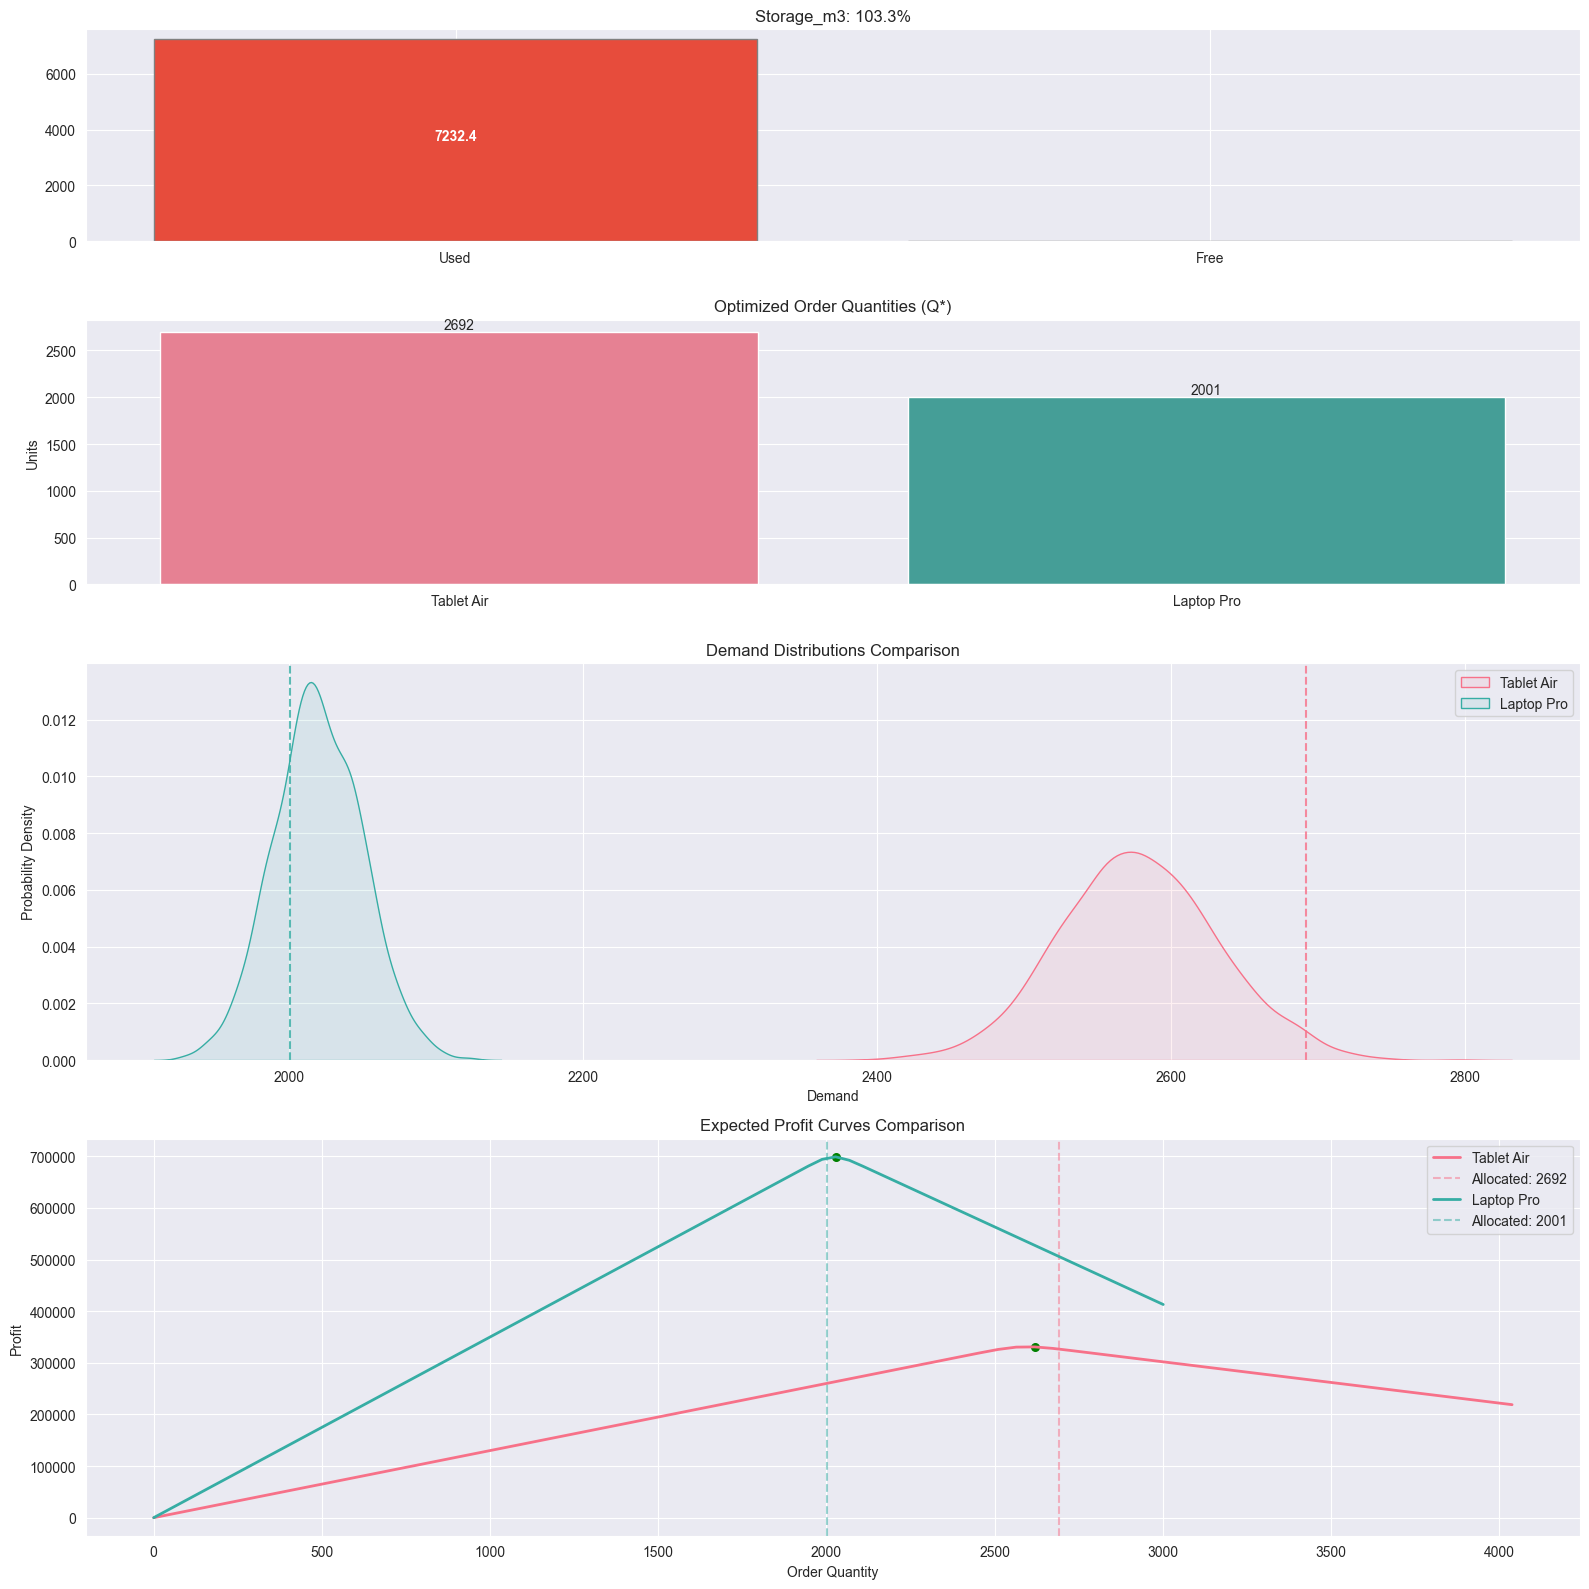

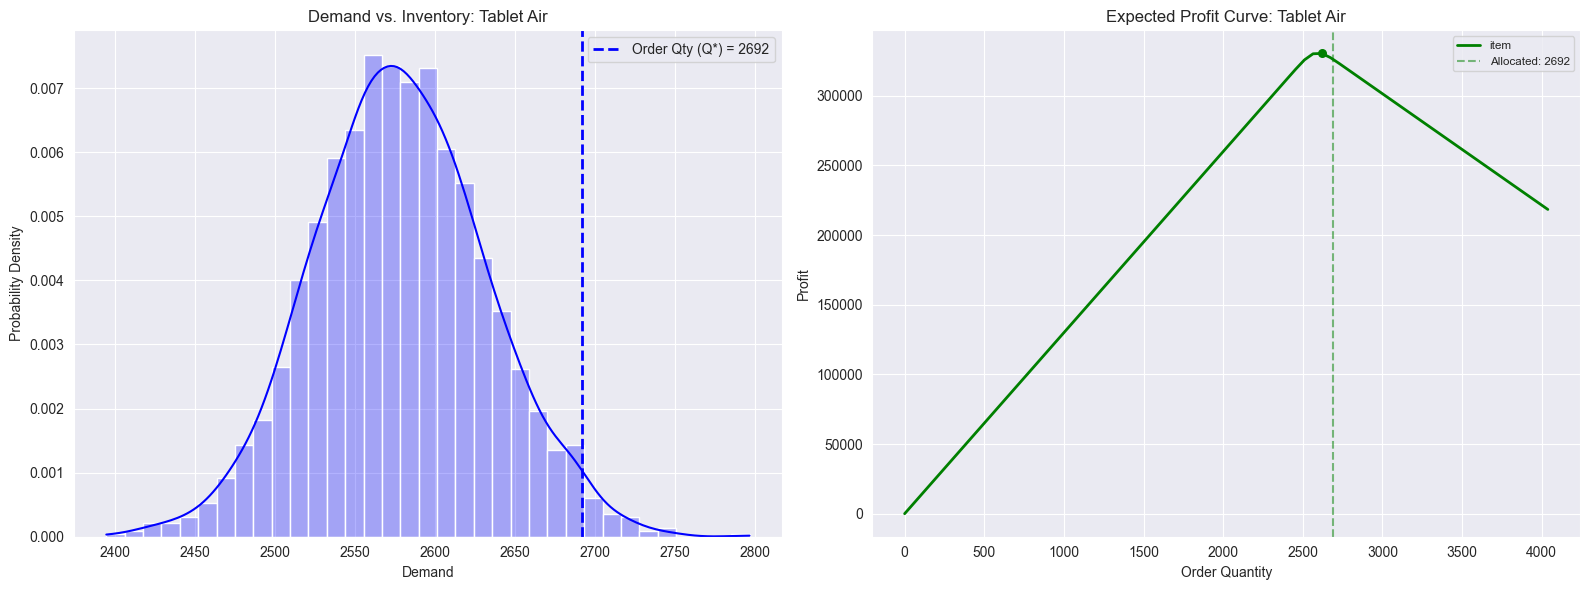

In [6]:
# Allocation chart: service floor shifts Tablet Air Q* to the right of the
# profit-optimal quantity, while Laptop Pro remains at the profit optimum
sk_svc.plot_allocation()
plt.show()

# Single-item view: demand distribution + profit curve for Tablet Air
# The dashed Q* line sits at the 95th-percentile floor, not the profit peak
sk_svc.plot_item("Tablet Air")
plt.show()

---
## Part 3 — `ContinuousFixedQuantity` (s, Q)

Monitors inventory **continuously** and places an order of fixed quantity **Q**
whenever the inventory position falls to or below reorder point **s**.

Instead of an order quantity, `run()` returns a **distribution of days-to-first-reorder**
across all Bayesian posterior demand scenarios — answering *when* you are likely to
need to reorder, not how much.

| Parameter | Where | Description |
|---|---|---|
| `Q` | constructor | `{item_name: int}` — fixed order quantity (required) |
| `reorder_points` | constructor | `{item_name: float}` — reorder point s; auto-computed from `service_level` quantile of lead-time demand when omitted |
| `service_level` | constructor | Quantile for auto-computing s (default 0.95) |
| `inventory_state` | `run()` | Starting inventory position for the simulation |

The same Bayesian forecasting pipeline runs under the hood. Daily posterior samples
drive the inventory simulation rather than the newsvendor solver.

In [7]:
from optistock.stockkeep import ContinuousFixedQuantity

# Q = 1 000 units per replenishment order; s auto-computed from posterior lead-time demand
sk_cfq = ContinuousFixedQuantity(
    histories=df_tablet,
    item_configs=item_configs_tablet,
    Q={"Tablet Air": 1_000},
    service_level=0.90,          # used to auto-compute reorder point s
    forecaster_class=BayesTimeSeries,
    forecaster_kwargs={"seasonal_config": seasonal_config},
    yield_profiles=yield_profiles,
)

# Simulate 30 days forward from current inventory
cfq_results = sk_cfq.run(
    forecast_days=30,
    inventory_state={"Tablet Air": {"on_hand": 1_500, "on_order": 0}},
    fit_kwargs={"chain": 2, "samples": 500},
)

print(f"Period : {cfq_results['period'][0]}  →  {cfq_results['period'][1]}")
print(f"Mode   : {cfq_results['mode']}")
print()
print("Stockout day array shape:", cfq_results["stockout_days"]["Tablet Air"].shape,
      " (one value per posterior draw)")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, growth, beta_event, beta_fourier, sigma]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 20 seconds.
Sampling: [y]


Output()

Sampling: [y]


Output()

Period : 2024-01-01  →  2024-01-30
Mode   : production

Stockout day array shape: (30,)  (one value per posterior draw)


'Tablet Air': The 90% HDI says a stockout will occur between day 12 and day 15  (100.0% of scenarios result in a stockout within 2000 days).

Order 1,000 units of 'Tablet Air' by day 7 (lead time 5d, 5% stockout risk tolerance).
Order 1,000 units of 'Tablet Air' by day 7 (lead time 5d, 20% stockout risk tolerance).



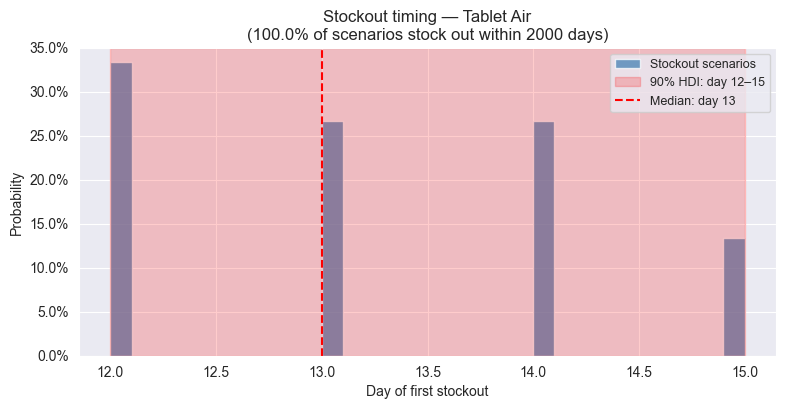

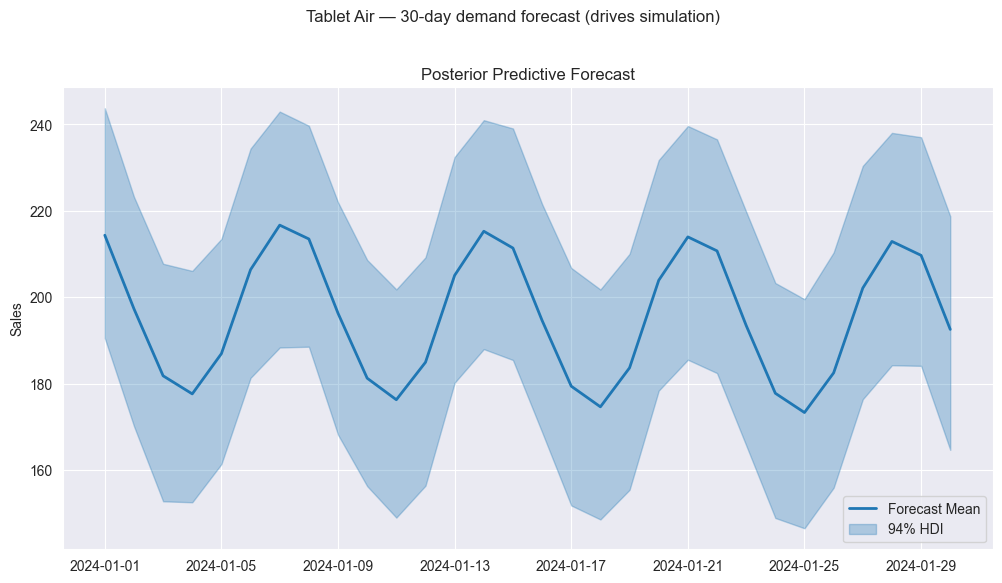

In [8]:
# --- Stockout report ---
print(sk_cfq.report("Tablet Air", hdi_prob=0.90))
print()

# --- Recommended order day at two risk tolerances ---
for rt in [0.05, 0.20]:
    rec = sk_cfq.recommended_order_day("Tablet Air", risk_tolerance=rt)
    print(rec["action"])
print()

# --- Plots ---
fig = sk_cfq.plot_stockout_distribution("Tablet Air", hdi_prob=0.90)
plt.show()

fig, _ = sk_cfq.plot_forecast("Tablet Air")
fig.suptitle("Tablet Air — 30-day demand forecast (drives simulation)", y=1.01)
plt.show()

## Part 4 — `ContinuousOrderUpTo` (s, S)

The **(s, S)** policy is the adaptive sibling of **(s, Q)**. Instead of ordering a fixed quantity Q every time, the order brings inventory back **up to a target level S** — so the order quantity varies with how far inventory has drifted below the reorder point.

| Feature | (s, Q) `ContinuousFixedQuantity` | (s, S) `ContinuousOrderUpTo` |
|---------|----------------------------------|------------------------------|
| Trigger | inventory ≤ s | inventory ≤ s |
| Order size | fixed Q | S − inventory position |
| Larger orders when stock is very low | ✗ | ✓ |
| Simpler to execute | ✓ | ✗ |

**`run()` returns**

```python
{
    "stockout_days": {"Tablet Air": np.ndarray},   # one value per posterior draw
    "period": ("2025-01-01", "2025-01-30"),
    "mode": "production",
}
```

**Analysis methods**

| Method | Description |
|--------|-------------|
| `report(item, hdi_prob=0.90)` | HDI statement: "stockout between day X and day Y" |
| `plot_stockout_distribution(item)` | Histogram of first-stockout day + HDI band |
| `recommended_order_day(item, risk_tolerance=0.10)` | "Top up to S by day X" |

In [9]:
from optistock.stockkeep import ContinuousOrderUpTo

# S = 2 500 — order-up-to level; s auto-computed at 90th pct of lead-time demand
sk_cou = ContinuousOrderUpTo(
    histories=df_tablet,
    item_configs=item_configs_tablet,
    S={"Tablet Air": 2_500},
    service_level=0.90,
    forecaster_class=BayesTimeSeries,
    forecaster_kwargs={"seasonal_config": seasonal_config},
    yield_profiles=yield_profiles,
)

cou_results = sk_cou.run(
    forecast_days=30,
    inventory_state={"Tablet Air": {"on_hand": 1_500, "on_order": 0}},
    fit_kwargs={"chain": 2, "samples": 500},
)

print(f"Period : {cou_results['period'][0]}  →  {cou_results['period'][1]}")
print()

# --- Stockout report ---
print(sk_cou.report("Tablet Air", hdi_prob=0.90))
print()

# --- Recommended order dates ---
for rt in [0.05, 0.20]:
    rec = sk_cou.recommended_order_day("Tablet Air", risk_tolerance=rt)
    print(rec["action"])
print()

# --- Side-by-side comparison with CFQ ---
cfq_sd = cfq_results["stockout_days"]["Tablet Air"]
cou_sd = cou_results["stockout_days"]["Tablet Air"]
horizon = 30

print("─" * 60)
print("(s, Q)  vs  (s, S) — same starting inventory, same horizon")
print("─" * 60)
for label, sd in [("Fixed Q=1 000", cfq_sd), ("Order-up-to S=2 500", cou_sd)]:
    pct = 100 * np.mean(sd <= horizon)
    finite = sd[sd <= horizon]
    med = f"  median day {np.median(finite):.0f}" if len(finite) else ""
    print(f"  {label:<22}: {pct:5.1f}% stock out within 30 d{med}")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, growth, beta_event, beta_fourier, sigma]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 21 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y]


Output()

Sampling: [y]


Output()

Period : 2024-01-01  →  2024-01-30

'Tablet Air': The 90% HDI says a stockout will occur between day 14 and day 18  (100.0% of scenarios result in a stockout within 2000 days).

Top up 'Tablet Air' to 2,500 units by day 9 (lead time 5d, 5% stockout risk tolerance).
Top up 'Tablet Air' to 2,500 units by day 9 (lead time 5d, 20% stockout risk tolerance).

────────────────────────────────────────────────────────────
(s, Q)  vs  (s, S) — same starting inventory, same horizon
────────────────────────────────────────────────────────────
  Fixed Q=1 000         : 100.0% stock out within 30 d  median day 13
  Order-up-to S=2 500   : 100.0% stock out within 30 d  median day 16


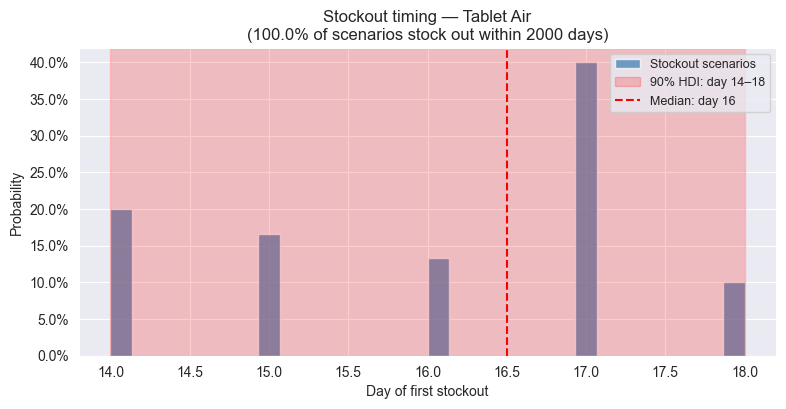

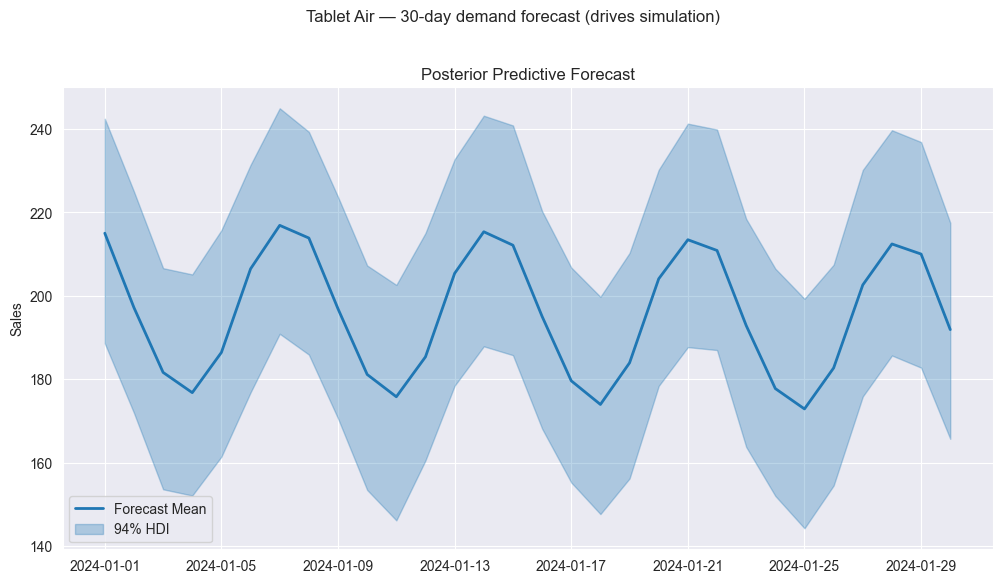

In [10]:
fig = sk_cou.plot_stockout_distribution("Tablet Air", hdi_prob=0.90)
plt.show()

fig, _ = sk_cou.plot_forecast("Tablet Air")
fig.suptitle("Tablet Air — 30-day demand forecast (drives simulation)", y=1.01)
plt.show()

---
## Summary

| Class | Policy | Review | Key parameters | Returns |
|---|---|---|---|---|
| `PeriodicOrderUpTo` | (R, S) | Periodic | `review_period` | `allocation`, `net_allocation`, `solver_summary` |
| `PeriodicBaseStock` | (R, S) + CSL | Periodic | `review_period`, `service_targets` | Same + CSL floor enforced |
| `ContinuousFixedQuantity` | (s, Q) | Continuous | `Q` (fixed qty), `service_level` | `reorder_distribution`, `policy_parameters` |
| `ContinuousOrderUpTo` | (s, S) | Continuous | `S` (up-to level), `service_level` | `reorder_distribution`, `policy_parameters` |

**Periodic classes** use the full Bayesian newsvendor pipeline:
fit → forecast → posterior samples → `ForecastSolver` → `allocation`.
The protection interval is always `lead_time + review_period`.

**Continuous classes** bypass the solver entirely:
fit → forecast → posterior samples → Monte Carlo simulation → `reorder_distribution`.
The reorder point `s` is auto-computed as the `service_level` quantile of lead-time demand when not supplied.

### Choosing the right class

- You review on a fixed schedule and want maximum expected profit → **`PeriodicOrderUpTo`**
- Same as above, but with a service-level guarantee on some items → **`PeriodicBaseStock`**
- You can monitor inventory daily and want simple, ERP-friendly rules → **`ContinuousFixedQuantity`** (s, Q)
- Daily monitoring, but you want to top up to a consistent inventory level → **`ContinuousOrderUpTo`** (s, S)

### Common interface

All four classes share the same forecasting back-end and these entry points:

```python
# Validate on historical data
results = policy.run_holdout(holdout_days=..., **solver_kwargs)

# Production allocation / simulation
results = policy.run(forecast_days=..., inventory_state={...}, **solver_kwargs)

# Forecast diagnostics
fig, ax = policy.plot_forecast(item_name)
```